In [21]:
# imports
import kagglehub
import plotly.graph_objects as go
import ipywidgets as widgets
import pandas as pd
from prophet import Prophet

from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
import numpy as np

#path = kagglehub.dataset_download("hrishitpatil/flight-data-2024")

#print("Path to dataset files:", path)



In [22]:
# reading file
df1 = pd.read_csv("flight_delays.csv")

# using JFK
df1 = df1[df1['Origin'] == 'JFK'].copy()



In [23]:
# second dataset
df2 = pd.read_csv("flight_data_2024.csv")

# JFK
if 'origin' in df2.columns:
    df2 = df2[df2['origin'] == 'JFK'].copy()

# Convert to datetime
df2['fl_date'] = pd.to_datetime(df2['fl_date'], errors='coerce')



df2.reset_index(drop=True, inplace=True)

C:\Users\Branka\AppData\Local\Temp\ipykernel_23224\2831474629.py:1: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("flight_data_2024.csv")


In [24]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123348 entries, 0 to 123347
Data columns (total 35 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   year                 123348 non-null  int64         
 1   month                123348 non-null  int64         
 2   day_of_month         123348 non-null  int64         
 3   day_of_week          123348 non-null  int64         
 4   fl_date              123348 non-null  datetime64[ns]
 5   op_unique_carrier    123348 non-null  object        
 6   op_carrier_fl_num    123348 non-null  float64       
 7   origin               123348 non-null  object        
 8   origin_city_name     123348 non-null  object        
 9   origin_state_nm      123348 non-null  object        
 10  dest                 123348 non-null  object        
 11  dest_city_name       123348 non-null  object        
 12  dest_state_nm        123348 non-null  object        
 13  crs_dep_time  

In [25]:
df1.head()

,FlightID,Airline,FlightNumber,Origin,Destination,ScheduledDeparture,ActualDeparture,ScheduledArrival,ActualArrival,DelayMinutes,DelayReason,Cancelled,Diverted,AircraftType,TailNumber,Distance
10,11,American Airlines,9317,JFK,MIA,2024-09-01 20:57,2024-09-01 21:19,2024-09-01 21:57,2024-09-01 21:51,-6,NaN,True,True,Airbus A320,N54905,2848
17,18,United,2966,JFK,SEA,2024-09-01 03:04,2024-09-01 03:11,2024-09-01 04:04,2024-09-01 03:54,-10,NaN,True,False,Airbus A320,N26442,701
18,19,American Airlines,390,JFK,BOS,2024-09-01 01:52,2024-09-01 02:03,2024-09-01 07:52,2024-09-01 08:18,26,Weather,True,True,Airbus A320,N65966,2268
23,24,Delta,8277,JFK,JFK,2024-09-01 01:27,2024-09-01 01:40,2024-09-01 02:27,2024-09-01 02:53,26,Maintenance,True,False,Boeing 737,N40985,2198
25,26,Delta,5396,JFK,SFO,2024-09-01 08:33,2024-09-01 09:01,2024-09-01 09:33,2024-09-01 09:59,26,Air Traffic Control,True,True,Boeing 737,N26788,2780


In [26]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 349208 entries, 10 to 1747625
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   FlightID            349208 non-null  int64 
 1   Airline             349208 non-null  object
 2   FlightNumber        349208 non-null  int64 
 3   Origin              349208 non-null  object
 4   Destination         349208 non-null  object
 5   ScheduledDeparture  349208 non-null  object
 6   ActualDeparture     349208 non-null  object
 7   ScheduledArrival    349208 non-null  object
 8   ActualArrival       349208 non-null  object
 9   DelayMinutes        349208 non-null  int64 
 10  DelayReason         255750 non-null  object
 11  Cancelled           349208 non-null  bool  
 12  Diverted            349208 non-null  bool  
 13  AircraftType        349208 non-null  object
 14  TailNumber          349208 non-null  object
 15  Distance            349208 non-null  int64 
dtypes: bo

In [27]:
df2.head()


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4828.0,JFK,"New York, NY",New York,...,0,71.0,57.0,41.0,189.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4900.0,JFK,"New York, NY",New York,...,0,164.0,141.0,113.0,718.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4904.0,JFK,"New York, NY",New York,...,0,219.0,180.0,143.0,1113.0,0,0,0,0,0


In [28]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123348 entries, 0 to 123347
Data columns (total 35 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   year                 123348 non-null  int64         
 1   month                123348 non-null  int64         
 2   day_of_month         123348 non-null  int64         
 3   day_of_week          123348 non-null  int64         
 4   fl_date              123348 non-null  datetime64[ns]
 5   op_unique_carrier    123348 non-null  object        
 6   op_carrier_fl_num    123348 non-null  float64       
 7   origin               123348 non-null  object        
 8   origin_city_name     123348 non-null  object        
 9   origin_state_nm      123348 non-null  object        
 10  dest                 123348 non-null  object        
 11  dest_city_name       123348 non-null  object        
 12  dest_state_nm        123348 non-null  object        
 13  crs_dep_time  

In [29]:
import pandas as pd
import numpy as np
import holidays

# Standardize first datafram
df1['ScheduledDeparture'] = pd.to_datetime(df1['ScheduledDeparture'])
df1['ScheduledArrival']   = pd.to_datetime(df1['ScheduledArrival'])

# standardize second dataframe
df2['ScheduledDeparture'] = pd.to_datetime(
    df2['fl_date'].astype(str) + ' ' + df2['crs_dep_time'].astype(str).str.zfill(4).str[:2] + ':' +
    df2['crs_dep_time'].astype(str).str.zfill(4).str[2:], errors='coerce'
)
df2['ScheduledArrival'] = df2['ScheduledDeparture'] + pd.to_timedelta(df2['crs_elapsed_time'], unit='m')

# rename columns
df2.rename(columns={
    'op_unique_carrier':'Airline',
    'op_carrier_fl_num':'FlightNumber',
    'origin':'Origin',
    'dest':'Destination',
    'distance':'Distance',
    'cancelled':'Cancelled',
    'diverted':'Diverted',
    'dep_delay':'DelayMinutes'
}, inplace=True)

# columns to keep
cols_to_keep = ['Airline','FlightNumber','Origin','Destination',
                'ScheduledDeparture','ScheduledArrival',
                'DelayMinutes','Cancelled','Diverted','Distance']

df1 = df1[cols_to_keep]
df2 = df2[cols_to_keep]


# merge datasets
df_all = pd.concat([df1, df2], ignore_index=True)
df_all = df_all.sort_values('ScheduledDeparture').reset_index(drop=True)

# Round to hourly
df_all['Hour'] = df_all['ScheduledDeparture'].dt.floor('H')

# Aggregate to hourly averages
numeric_cols = ['DelayMinutes','Distance','Cancelled','Diverted']
df_hourly = df_all.groupby('Hour')[numeric_cols].mean().reset_index()
df_hourly['FlightCount'] = df_all.groupby('Hour').size().values

# adding time features
df_hourly['HourOfDay'] = df_hourly['Hour'].dt.hour
df_hourly['DayOfWeek'] = df_hourly['Hour'].dt.dayofweek
df_hourly['Month']     = df_hourly['Hour'].dt.month
df_hourly['IsWeekend'] = df_hourly['DayOfWeek'].isin([5,6]).astype(int)

# holiday feature
us_holidays = holidays.US()
df_hourly['IsHoliday'] = df_hourly['Hour'].dt.floor('D').isin(us_holidays).astype(int)


# For each origin, count flights and average delay in past 3h and 24h
origin_features = []
for origin, g in df_all.groupby('Origin'):
    g = g.sort_values('ScheduledDeparture').copy()
    g_idx = g.set_index('ScheduledDeparture')
    tmp = pd.DataFrame(index=g_idx.index)
    tmp[f'{origin}_Flights_3h'] = g_idx['DelayMinutes'].rolling('3h').count()
    tmp[f'{origin}_AvgDelay_3h'] = g_idx['DelayMinutes'].rolling('3h').mean()
    tmp[f'{origin}_AvgDelay_24h'] = g_idx['DelayMinutes'].rolling('24h').mean()
    origin_features.append(tmp)
origin_df = pd.concat(origin_features, axis=1)

# Aggregate hourly
origin_hourly = origin_df.resample('H').mean().reset_index()
df_hourly = df_hourly.merge(origin_hourly, left_on='Hour', right_on='ScheduledDeparture', how='left')
df_hourly.drop(columns=['ScheduledDeparture'], inplace=True, errors='ignore')

# lag feature
df_hourly['DelayLastWeekSameHour'] = df_hourly['DelayMinutes'].shift(168)  # 168 hours = 1 week

print("Final hourly dataset ready!")
print(df_hourly.head())


C:\Users\Branka\AppData\Local\Temp\ipykernel_23224\154026403.py:53: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_all['Hour'] = df_all['ScheduledDeparture'].dt.floor('H')


Final hourly dataset ready!
                 Hour  DelayMinutes     Distance  Cancelled  Diverted  \
0 2024-01-01 05:00:00    -13.000000  1028.000000        0.0       0.0   
1 2024-01-01 06:00:00      1.142857  1236.571429        0.0       0.0   
2 2024-01-01 07:00:00     -0.956522  1398.000000        0.0       0.0   
3 2024-01-01 08:00:00      2.423077  1361.576923        0.0       0.0   
4 2024-01-01 09:00:00      3.666667  1290.611111        0.0       0.0   

   FlightCount  HourOfDay  DayOfWeek  Month  IsWeekend  IsHoliday  \
0            1          5          0      1          0          0   
1           14          6          0      1          0          0   
2           23          7          0      1          0          0   
3           26          8          0      1          0          0   
4           18          9          0      1          0          0   

   JFK_Flights_3h  JFK_AvgDelay_3h  JFK_AvgDelay_24h  DelayLastWeekSameHour  
0        1.000000       -13.000000      

C:\Users\Branka\AppData\Local\Temp\ipykernel_23224\154026403.py:93: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  origin_hourly = origin_df.resample('H').mean().reset_index()


In [30]:
df_hourly.head()

,Hour,DelayMinutes,Distance,Cancelled,Diverted,FlightCount,HourOfDay,DayOfWeek,Month,IsWeekend,IsHoliday,JFK_Flights_3h,JFK_AvgDelay_3h,JFK_AvgDelay_24h,DelayLastWeekSameHour
0,2024-01-01 05:00:00,-13.000000,1028.000000,0.0,0.0,1,5,0,1,0,0,1.000000,-13.000000,-13.000000,NaN
1,2024-01-01 06:00:00,1.142857,1236.571429,0.0,0.0,14,6,0,1,0,0,8.500000,0.733918,0.733918,NaN
2,2024-01-01 07:00:00,-0.956522,1398.000000,0.0,0.0,23,7,0,1,0,0,27.000000,0.386681,0.386681,NaN
3,2024-01-01 08:00:00,2.423077,1361.576923,0.0,0.0,26,8,0,1,0,0,51.076923,1.268897,1.165757,NaN
4,2024-01-01 09:00:00,3.666667,1290.611111,0.0,0.0,18,9,0,1,0,0,67.277778,0.878873,0.940293,NaN


In [31]:
df_hourly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6788 entries, 0 to 6787
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Hour                   6788 non-null   datetime64[ns]
 1   DelayMinutes           6776 non-null   float64       
 2   Distance               6788 non-null   float64       
 3   Cancelled              6788 non-null   float64       
 4   Diverted               6788 non-null   float64       
 5   FlightCount            6788 non-null   int64         
 6   HourOfDay              6788 non-null   int32         
 7   DayOfWeek              6788 non-null   int32         
 8   Month                  6788 non-null   int32         
 9   IsWeekend              6788 non-null   int64         
 10  IsHoliday              6788 non-null   int64         
 11  JFK_Flights_3h         6788 non-null   float64       
 12  JFK_AvgDelay_3h        6787 non-null   float64       
 13  JFK

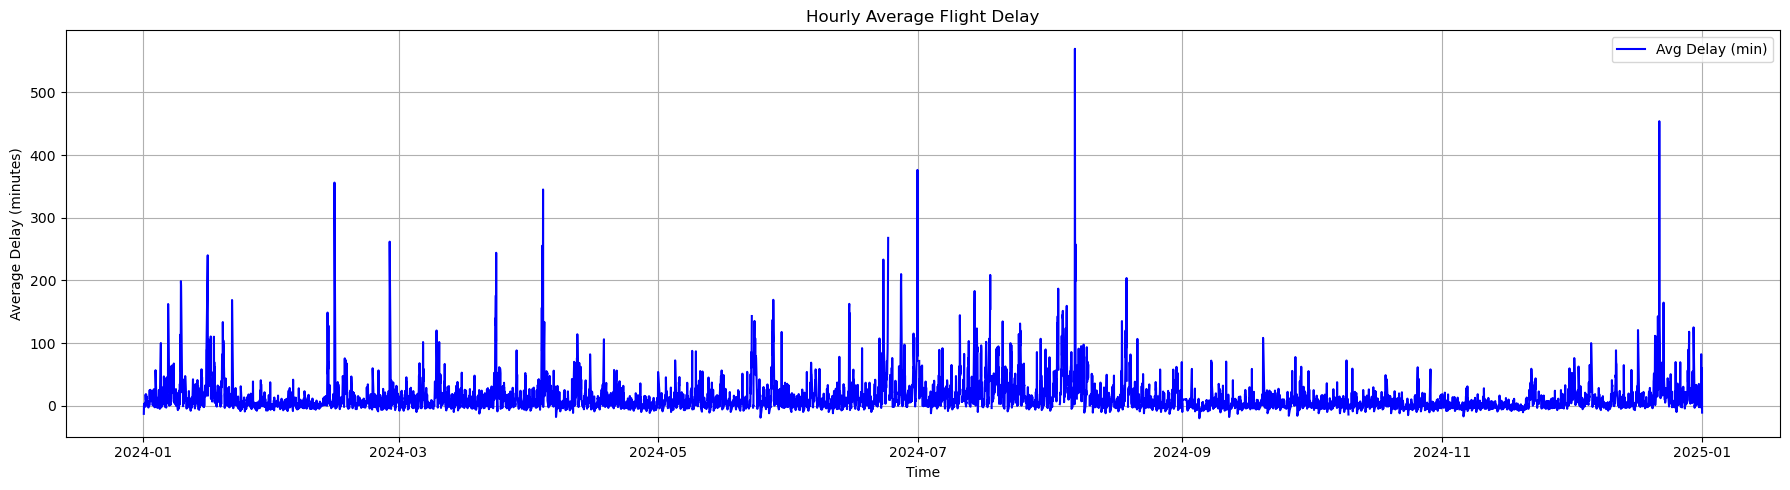

In [32]:
import matplotlib.pyplot as plt

# Plotting hourly average delay
plt.figure(figsize=(18,5))
plt.plot(df_hourly['Hour'], df_hourly['DelayMinutes'], color='blue', label='Avg Delay (min)')
plt.xlabel('Time')
plt.ylabel('Average Delay (minutes)')
plt.title('Hourly Average Flight Delay')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
#Dropping features that wouldn't be knwon by people using the service
columns_to_drop = ['FlightID', 'TailNumber', 'Diverted', 'Cancelled', 'DelayReason', 'AircraftType', 'ActualArrival', 'ActualDeparture']
df_all = df_all.drop(columns=columns_to_drop, errors='ignore')  # errors='ignore' avoids issues if a column doesn't exist



In [34]:
df_all = df_hourly
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6788 entries, 0 to 6787
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Hour                   6788 non-null   datetime64[ns]
 1   DelayMinutes           6776 non-null   float64       
 2   Distance               6788 non-null   float64       
 3   Cancelled              6788 non-null   float64       
 4   Diverted               6788 non-null   float64       
 5   FlightCount            6788 non-null   int64         
 6   HourOfDay              6788 non-null   int32         
 7   DayOfWeek              6788 non-null   int32         
 8   Month                  6788 non-null   int32         
 9   IsWeekend              6788 non-null   int64         
 10  IsHoliday              6788 non-null   int64         
 11  JFK_Flights_3h         6788 non-null   float64       
 12  JFK_AvgDelay_3h        6787 non-null   float64       
 13  JFK

X_train_seq: (5411, 24, 13)
y_train_seq: (5411,)
X_test_seq: (1353, 24, 13)
y_test_seq: (1353,)
Testing CNN params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'filters': 32, 'kernel_size': 2, 'learning_rate': 0.001}


C:\Users\Branka\AppData\Local\Temp\ipykernel_23224\2060241921.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_all = df_all.fillna(method='ffill').fillna(method='bfill')
c:\Users\Branka\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Testing CNN params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'filters': 32, 'kernel_size': 2, 'learning_rate': 0.0005}


c:\Users\Branka\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Testing CNN params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'filters': 32, 'kernel_size': 3, 'learning_rate': 0.001}


...

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Testing CNN params: {'batch_size': 64, 'dropout': 0.2, 'epochs': 50, 'filters': 64, 'kernel_size': 3, 'learning_rate': 0.001}


c:\Users\Branka\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Testing CNN params: {'batch_size': 64, 'dropout': 0.2, 'epochs': 50, 'filters': 64, 'kernel_size': 3, 'learning_rate': 0.0005}


c:\Users\Branka\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Best CNN params: {'batch_size': 32, 'dropout': 0.2, 'epochs': 50, 'filters': 64, 'kernel_size': 2, 'learning_rate': 0.0005}


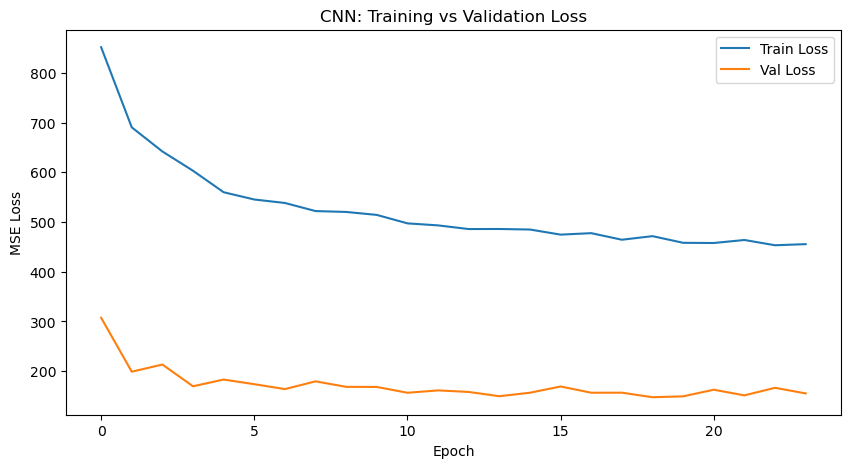

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


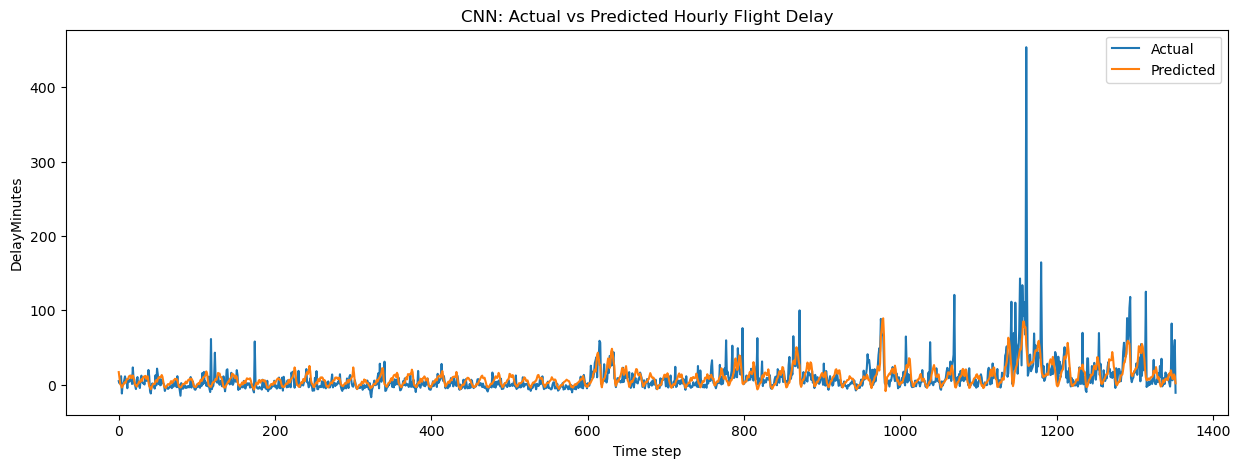

CNN -> MAE: 9.391, MSE: 335.323, RMSE: 18.312


In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# target variable
target_col = "DelayMinutes"

# Fill NaNs
df_all = df_all.fillna(method='ffill').fillna(method='bfill')

# Use numeric features only
numeric_cols = df_all.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove(target_col)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_all[numeric_cols].astype(np.float32))
y = df_all[target_col].astype(np.float32).values

# Create sequences for CNN
seq_len = 24  # past 24 hours to predict next hour
def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y, seq_len)

# Split train/test sets
split_idx = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split_idx], X_seq[split_idx:]
y_train_seq, y_test_seq = y_seq[:split_idx], y_seq[split_idx:]

print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)
print("X_test_seq:", X_test_seq.shape)
print("y_test_seq:", y_test_seq.shape)

# hyperparameters
param_grid_cnn = {
    "filters": [32, 64],
    "kernel_size": [2, 3],
    "dropout": [0.1, 0.2],
    "learning_rate": [0.001, 0.0005],
    "batch_size": [32, 64],
    "epochs": [50]
}

# build CNN
def build_cnn(input_shape, filters=32, kernel_size=2, dropout=0.2, lr=0.001):
    model = Sequential([
        Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', input_shape=input_shape),
        Dropout(dropout),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(dropout),
        Dense(1, activation='linear')
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# best metrics placeholder
best_mse = float("inf")
best_params_cnn = {}
best_cnn_model = None

# searching
for params in ParameterGrid(param_grid_cnn):
    print("Testing CNN params:", params)
    model = build_cnn(
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
        filters=params['filters'],
        kernel_size=params['kernel_size'],
        dropout=params['dropout'],
        lr=params['learning_rate']
    )
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_split=0.2,
        epochs=params['epochs'],
        batch_size=params['batch_size'],
        callbacks=[es],
        verbose=0
    )
    y_pred_val = model.predict(X_test_seq)
    mse = mean_squared_error(y_test_seq, y_pred_val)
    
    if mse < best_mse:
        best_mse = mse
        best_params_cnn = params
        best_cnn_model = model
        best_cnn_history = history

print("Best CNN params:", best_params_cnn)

# plotting
plt.figure(figsize=(10,5))
plt.plot(best_cnn_history.history['loss'], label='Train Loss')
plt.plot(best_cnn_history.history['val_loss'], label='Val Loss')
plt.title("CNN: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# plotting
y_pred_test_cnn = best_cnn_model.predict(X_test_seq).reshape(-1)
plt.figure(figsize=(15,5))
plt.plot(y_test_seq, label='Actual')
plt.plot(y_pred_test_cnn, label='Predicted')
plt.title("CNN: Actual vs Predicted Hourly Flight Delay")
plt.xlabel("Time step")
plt.ylabel("DelayMinutes")
plt.legend()
plt.show()

# metrics
mae = mean_absolute_error(y_test_seq, y_pred_test_cnn)
mse = mean_squared_error(y_test_seq, y_pred_test_cnn)
rmse = np.sqrt(mse)
print(f"CNN -> MAE: {mae:.3f}, MSE: {mse:.3f}, RMSE: {rmse:.3f}")


Testing LSTM params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'learning_rate': 0.001, 'units': 32}


c:\Users\Branka\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Params {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'learning_rate': 0.001, 'units': 32} -> MAE: 8.879, MSE: 350.258, RMSE: 18.715
Testing LSTM params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'learning_rate': 0.001, 'units': 64}


c:\Users\Branka\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Params {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'learning_rate': 0.001, 'units': 64} -> MAE: 10.734, MSE: 461.967, RMSE: 21.493
Testing LSTM params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'learning_rate': 0.0005, 'units': 32}


...

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Params {'batch_size': 64, 'dropout': 0.2, 'epochs': 50, 'learning_rate': 0.001, 'units': 64} -> MAE: 12.345, MSE: 544.868, RMSE: 23.342
Testing LSTM params: {'batch_size': 64, 'dropout': 0.2, 'epochs': 50, 'learning_rate': 0.0005, 'units': 32}


c:\Users\Branka\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Params {'batch_size': 64, 'dropout': 0.2, 'epochs': 50, 'learning_rate': 0.0005, 'units': 32} -> MAE: 10.472, MSE: 506.967, RMSE: 22.516
Testing LSTM params: {'batch_size': 64, 'dropout': 0.2, 'epochs': 50, 'learning_rate': 0.0005, 'units': 64}


c:\Users\Branka\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Params {'batch_size': 64, 'dropout': 0.2, 'epochs': 50, 'learning_rate': 0.0005, 'units': 64} -> MAE: 9.245, MSE: 386.242, RMSE: 19.653
Best LSTM params: {'batch_size': 32, 'dropout': 0.2, 'epochs': 50, 'learning_rate': 0.001, 'units': 64}


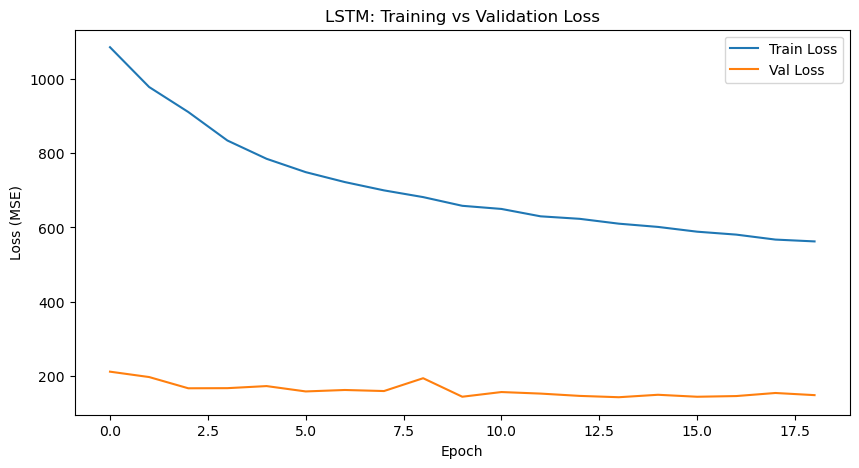

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


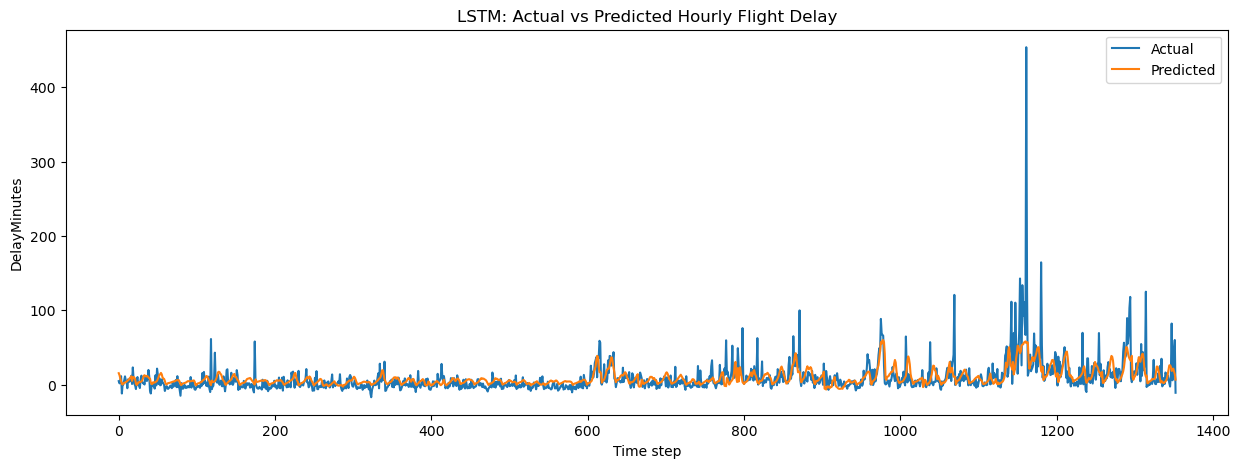

Best LSTM -> MAE: 9.265, MSE: 330.798, RMSE: 18.188


In [36]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# hyperparams
param_grid_lstm = {
    "units": [32, 64],
    "dropout": [0.1, 0.2],
    "learning_rate": [0.001, 0.0005],
    "batch_size": [32, 64],
    "epochs": [50]
}

# LSTM
def build_lstm(input_shape, units=32, dropout=0.2, lr=0.001):
    model = Sequential([
        LSTM(units, activation='tanh', return_sequences=False, input_shape=input_shape),
        Dropout(dropout),
        Dense(1, activation='linear')
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# Best hyperparams
best_mse = float("inf")
best_params_lstm = {}
best_lstm_model = None

for params in ParameterGrid(param_grid_lstm):
    print("Testing LSTM params:", params)
    model = build_lstm(
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
        units=params["units"],
        dropout=params["dropout"],
        lr=params["learning_rate"]
    )
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_split=0.2,
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        callbacks=[es],
        verbose=0
    )
    
    # Predict on test
    y_pred_test = model.predict(X_test_seq).reshape(-1)
    
    # Compute metrics
    mse = mean_squared_error(y_test_seq, y_pred_test)
    mae = mean_absolute_error(y_test_seq, y_pred_test)
    rmse = mse**0.5
    
    print(f"Params {params} -> MAE: {mae:.3f}, MSE: {mse:.3f}, RMSE: {rmse:.3f}")
    
    # Update best
    if mse < best_mse:
        best_mse = mse
        best_params_lstm = params
        best_lstm_model = model
        best_lstm_history = history

print("Best LSTM params:", best_params_lstm)

# plotting
plt.figure(figsize=(10,5))
plt.plot(best_lstm_history.history['loss'], label='Train Loss')
plt.plot(best_lstm_history.history['val_loss'], label='Val Loss')
plt.title("LSTM: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

# plotting
y_pred_test = best_lstm_model.predict(X_test_seq).reshape(-1)
plt.figure(figsize=(15,5))
plt.plot(y_test_seq, label='Actual')
plt.plot(y_pred_test, label='Predicted')
plt.title("LSTM: Actual vs Predicted Hourly Flight Delay")
plt.xlabel("Time step")
plt.ylabel("DelayMinutes")
plt.legend()
plt.show()

# Metrics
mae = mean_absolute_error(y_test_seq, y_pred_test)
mse = mean_squared_error(y_test_seq, y_pred_test)
rmse = mse**0.5
print(f"Best LSTM -> MAE: {mae:.3f}, MSE: {mse:.3f}, RMSE: {rmse:.3f}")


Testing RNN params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'learning_rate': 0.001, 'units': 32}


c:\Users\Branka\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Testing RNN params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'learning_rate': 0.001, 'units': 64}


c:\Users\Branka\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Testing RNN params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'learning_rate': 0.0005, 'units': 32}


...

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Testing RNN params: {'batch_size': 64, 'dropout': 0.2, 'epochs': 50, 'learning_rate': 0.0005, 'units': 32}


c:\Users\Branka\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Testing RNN params: {'batch_size': 64, 'dropout': 0.2, 'epochs': 50, 'learning_rate': 0.0005, 'units': 64}


c:\Users\Branka\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Best RNN params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'learning_rate': 0.001, 'units': 32}
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
RNN -> MAE: 11.22, MSE: 392.07, RMSE: 19.80


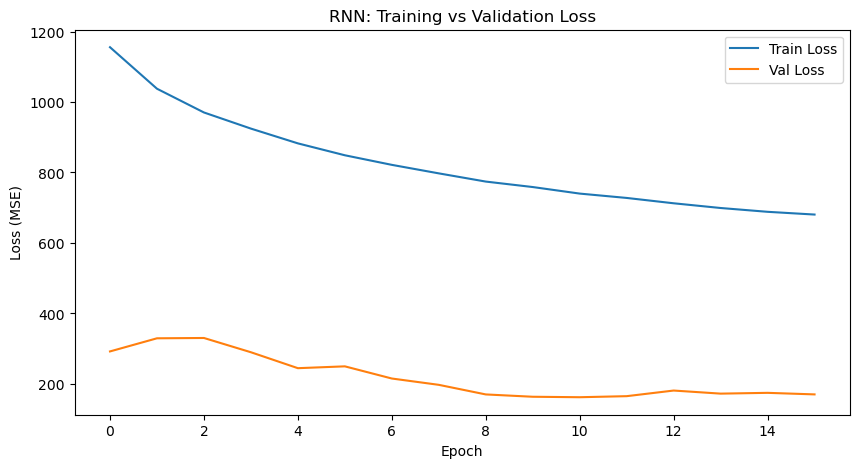

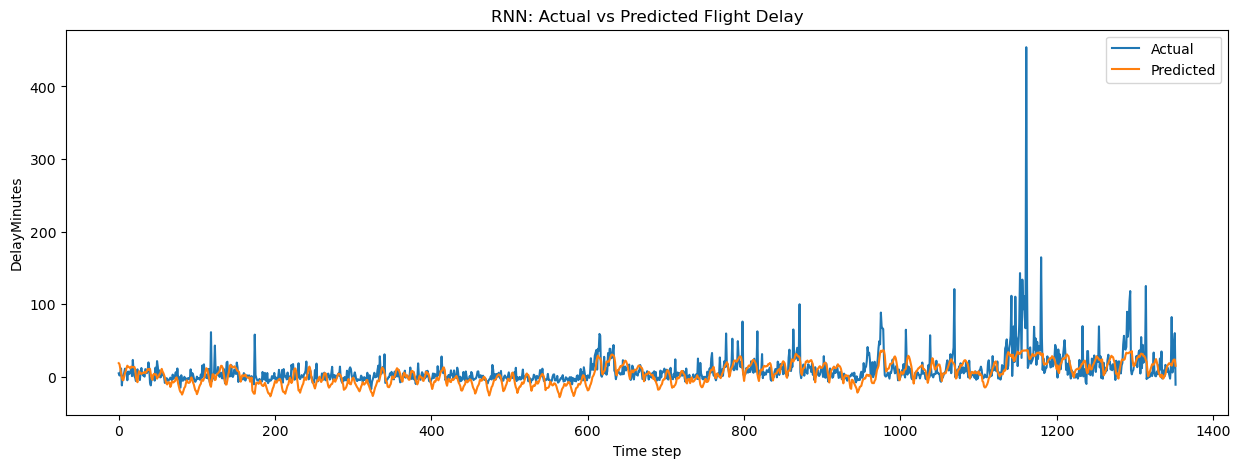

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Params
param_grid_rnn = {
    "units": [32, 64],
    "dropout": [0.1, 0.2],
    "learning_rate": [0.001, 0.0005],
    "batch_size": [32, 64],
    "epochs": [50]
}

# RNN
def build_rnn(input_shape, units=32, dropout=0.2, lr=0.001):
    model = Sequential([
        SimpleRNN(units, activation='tanh', input_shape=input_shape),
        Dropout(dropout),
        Dense(1)
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse')
    return model

# placeholders
best_mse = float("inf")
best_params_rnn = {}
best_rnn_model = None

# search
for params in ParameterGrid(param_grid_rnn):
    print("Testing RNN params:", params)
    model = build_rnn(
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
        units=params["units"],
        dropout=params["dropout"],
        lr=params["learning_rate"]
    )
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_split=0.2,
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        callbacks=[es],
        verbose=0
    )
    
    y_pred_val = model.predict(X_test_seq)
    mse_val = mean_squared_error(y_test_seq, y_pred_val)
    
    if mse_val < best_mse:
        best_mse = mse_val
        best_params_rnn = params
        best_rnn_model = model
        best_rnn_history = history

print("Best RNN params:", best_params_rnn)

# Metrics
y_pred_test_rnn = best_rnn_model.predict(X_test_seq)
mae = mean_absolute_error(y_test_seq, y_pred_test_rnn)
mse = mean_squared_error(y_test_seq, y_pred_test_rnn)
rmse = np.sqrt(mse)
print(f"RNN -> MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}")

# Plotting
plt.figure(figsize=(10,5))
plt.plot(best_rnn_history.history['loss'], label='Train Loss')
plt.plot(best_rnn_history.history['val_loss'], label='Val Loss')
plt.title("RNN: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

# plotting
plt.figure(figsize=(15,5))
plt.plot(y_test_seq, label='Actual')
plt.plot(y_pred_test_rnn, label='Predicted')
plt.title("RNN: Actual vs Predicted Flight Delay")
plt.xlabel("Time step")
plt.ylabel("DelayMinutes")
plt.legend()
plt.show()


Testing GRU params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'learning_rate': 0.001, 'units': 32}


c:\Users\Branka\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Testing GRU params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'learning_rate': 0.001, 'units': 64}


c:\Users\Branka\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Testing GRU params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'learning_rate': 0.0005, 'units': 32}


...

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Testing GRU params: {'batch_size': 64, 'dropout': 0.2, 'epochs': 50, 'learning_rate': 0.0005, 'units': 32}


c:\Users\Branka\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Testing GRU params: {'batch_size': 64, 'dropout': 0.2, 'epochs': 50, 'learning_rate': 0.0005, 'units': 64}


c:\Users\Branka\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Best GRU params: {'batch_size': 32, 'dropout': 0.2, 'epochs': 50, 'learning_rate': 0.001, 'units': 64}
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
GRU -> MAE: 8.96, MSE: 341.02, RMSE: 18.47


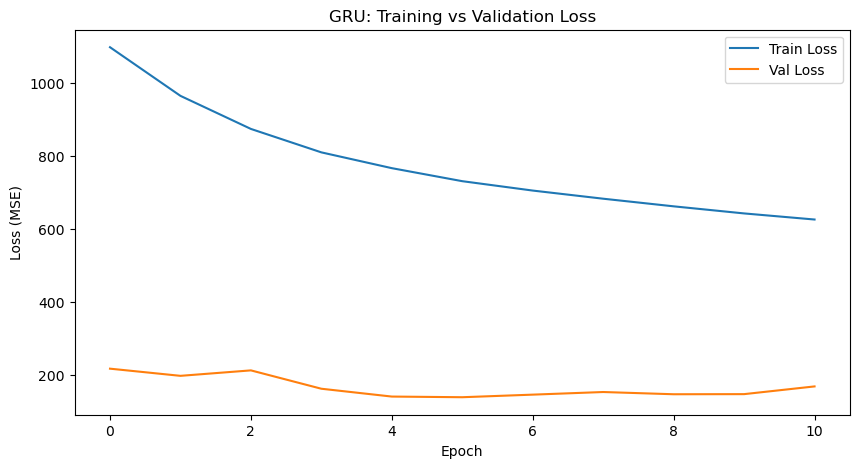

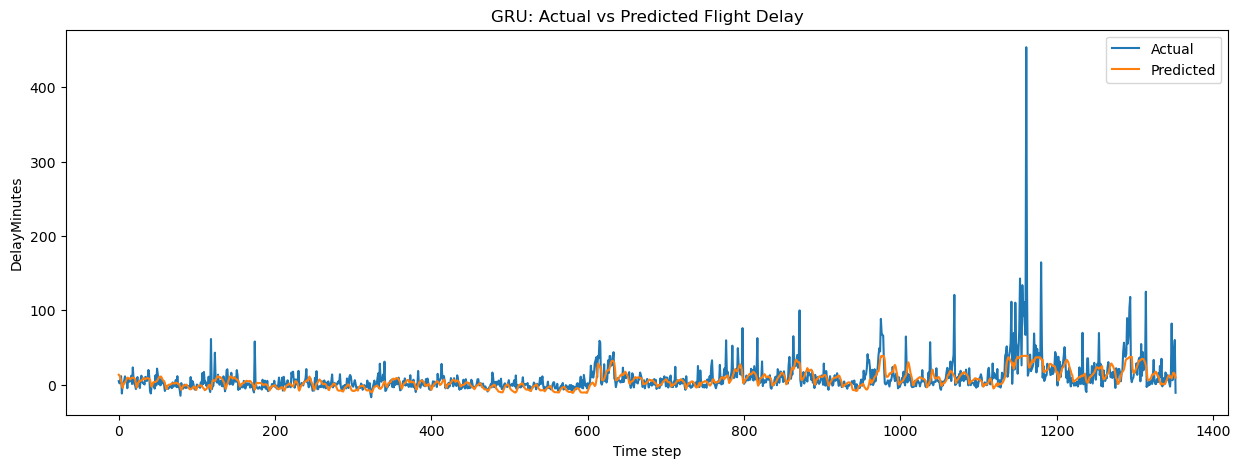

In [38]:
from tensorflow.keras.layers import GRU

# params
param_grid_gru = {
    "units": [32, 64],
    "dropout": [0.1, 0.2],
    "learning_rate": [0.001, 0.0005],
    "batch_size": [32, 64],
    "epochs": [50]
}

# GRU
def build_gru(input_shape, units=32, dropout=0.2, lr=0.001):
    model = Sequential([
        GRU(units, activation='tanh', input_shape=input_shape),
        Dropout(dropout),
        Dense(1)
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse')
    return model

# placeholder
best_mse = float("inf")
best_params_gru = {}
best_gru_model = None

# Searching
for params in ParameterGrid(param_grid_gru):
    print("Testing GRU params:", params)
    model = build_gru(
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
        units=params["units"],
        dropout=params["dropout"],
        lr=params["learning_rate"]
    )
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_split=0.2,
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        callbacks=[es],
        verbose=0
    )
    
    y_pred_val = model.predict(X_test_seq)
    mse_val = mean_squared_error(y_test_seq, y_pred_val)
    
    if mse_val < best_mse:
        best_mse = mse_val
        best_params_gru = params
        best_gru_model = model
        best_gru_history = history

print("Best GRU params:", best_params_gru)

# metrics
y_pred_test_gru = best_gru_model.predict(X_test_seq)
mae = mean_absolute_error(y_test_seq, y_pred_test_gru)
mse = mean_squared_error(y_test_seq, y_pred_test_gru)
rmse = np.sqrt(mse)
print(f"GRU -> MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}")

# plotting
plt.figure(figsize=(10,5))
plt.plot(best_gru_history.history['loss'], label='Train Loss')
plt.plot(best_gru_history.history['val_loss'], label='Val Loss')
plt.title("GRU: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

# plotting
plt.figure(figsize=(15,5))
plt.plot(y_test_seq, label='Actual')
plt.plot(y_pred_test_gru, label='Predicted')
plt.title("GRU: Actual vs Predicted Flight Delay")
plt.xlabel("Time step")
plt.ylabel("DelayMinutes")
plt.legend()
plt.show()


Testing FFNN params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'hidden_units': 32, 'learning_rate': 0.001}
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Testing FFNN params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'hidden_units': 32, 'learning_rate': 0.0005}
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Testing FFNN params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'hidden_units': 64, 'learning_rate': 0.001}
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Testing FFNN params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'hidden_units': 64, 'learning_rate': 0.0005}
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Testing FFNN params: {'batch_size': 32, 'dropout': 0.2, 'epochs': 50, 'hidden_units': 32, 'learning_rate': 0.001}
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Testing FFNN params: {'batch_size': 32, 'dropout': 0.2, 'epochs': 50, 'hidden_units': 32, 'learning_rate': 0.0005}
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Testing FFNN params: {'batch_size': 32, 'dropout': 0.2, 'epochs': 50, 'hi

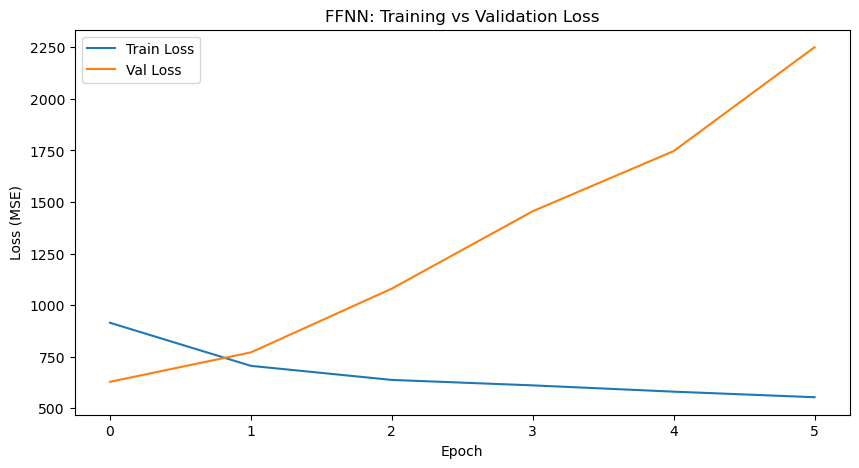

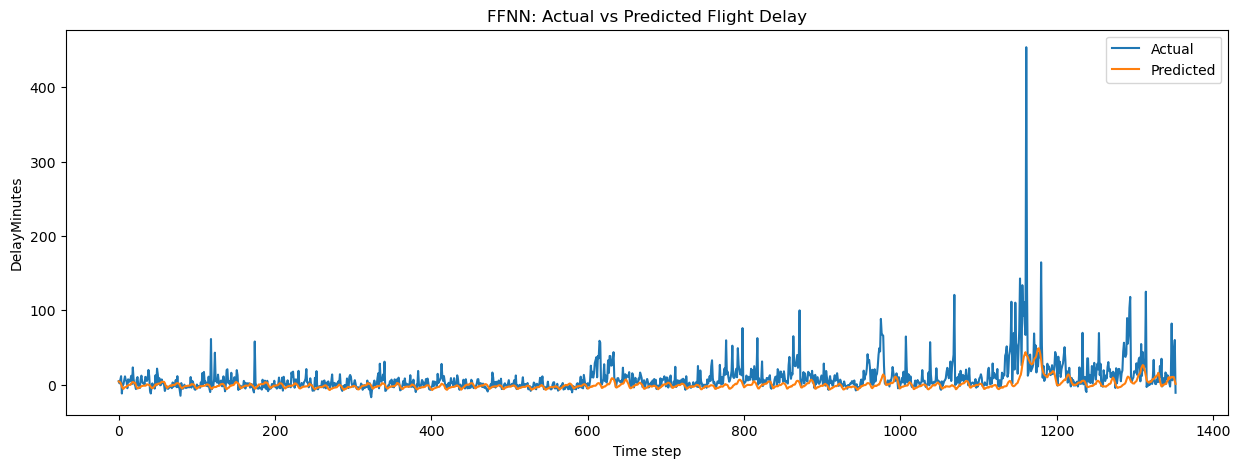

In [39]:
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model

# hyperparameters
param_grid_ffnn = {
    "hidden_units": [32, 64],
    "dropout": [0.1, 0.2],
    "learning_rate": [0.001, 0.0005],
    "batch_size": [32, 64],
    "epochs": [50]
}

# FFNN
def build_ffnn(input_shape, hidden_units=32, dropout=0.2, lr=0.001):
    inputs = Input(shape=(input_shape,))
    x = Dense(hidden_units, activation='relu')(inputs)
    x = Dropout(dropout)(x)
    outputs = Dense(1, activation='linear')(x)
    model = Model(inputs=inputs, outputs=outputs)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse')
    return model

# Flattening
X_train_ffnn = X_train_seq.reshape(X_train_seq.shape[0], -1)
X_test_ffnn  = X_test_seq.reshape(X_test_seq.shape[0], -1)

# placeholder
best_mse = float("inf")
best_params_ffnn = {}
best_ffnn_model = None

# searching
for params in ParameterGrid(param_grid_ffnn):
    print("Testing FFNN params:", params)
    model = build_ffnn(
        input_shape=X_train_ffnn.shape[1],
        hidden_units=params["hidden_units"],
        dropout=params["dropout"],
        lr=params["learning_rate"]
    )
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train_ffnn, y_train_seq,
        validation_split=0.2,
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        callbacks=[es],
        verbose=0
    )
    
    y_pred_val = model.predict(X_test_ffnn)
    mse_val = mean_squared_error(y_test_seq, y_pred_val)
    
    if mse_val < best_mse:
        best_mse = mse_val
        best_params_ffnn = params
        best_ffnn_model = model
        best_ffnn_history = history

print("Best FFNN params:", best_params_ffnn)

# metrics
y_pred_test_ffnn = best_ffnn_model.predict(X_test_ffnn)
mae = mean_absolute_error(y_test_seq, y_pred_test_ffnn)
mse = mean_squared_error(y_test_seq, y_pred_test_ffnn)
rmse = np.sqrt(mse)
print(f"FFNN -> MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}")

# plotting
plt.figure(figsize=(10,5))
plt.plot(best_ffnn_history.history['loss'], label='Train Loss')
plt.plot(best_ffnn_history.history['val_loss'], label='Val Loss')
plt.title("FFNN: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

# plotting
plt.figure(figsize=(15,5))
plt.plot(y_test_seq, label='Actual')
plt.plot(y_pred_test_ffnn, label='Predicted')
plt.title("FFNN: Actual vs Predicted Flight Delay")
plt.xlabel("Time step")
plt.ylabel("DelayMinutes")
plt.legend()
plt.show()


Testing TCN params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'kernel_size': 2, 'learning_rate': 0.001, 'nb_filters': 32}



c:\Users\Branka\anaconda3\Lib\site-packages\tcn\tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Params {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'kernel_size': 2, 'learning_rate': 0.001, 'nb_filters': 32} -> MAE: 10.038, MSE: 352.971, RMSE: 18.788
Testing TCN params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'kernel_size': 2, 'learning_rate': 0.001, 'nb_filters': 64}


c:\Users\Branka\anaconda3\Lib\site-packages\tcn\tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Params {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'kernel_size': 2, 'learning_rate': 0.001, 'nb_filters': 64} -> MAE: 11.302, MSE: 368.498, RMSE: 19.196
Testing TCN params: {'batch_size': 32, 'dropout': 0.1, 'epochs': 50, 'kernel_size': 2, 'learning_rate': 0.0005, 'nb_filters': 32}


...

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Params {'batch_size': 64, 'dropout': 0.2, 'epochs': 50, 'kernel_size': 3, 'learning_rate': 0.001, 'nb_filters': 64} -> MAE: 10.106, MSE: 335.902, RMSE: 18.328
Testing TCN params: {'batch_size': 64, 'dropout': 0.2, 'epochs': 50, 'kernel_size': 3, 'learning_rate': 0.0005, 'nb_filters': 32}


c:\Users\Branka\anaconda3\Lib\site-packages\tcn\tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Params {'batch_size': 64, 'dropout': 0.2, 'epochs': 50, 'kernel_size': 3, 'learning_rate': 0.0005, 'nb_filters': 32} -> MAE: 9.429, MSE: 350.247, RMSE: 18.715
Testing TCN params: {'batch_size': 64, 'dropout': 0.2, 'epochs': 50, 'kernel_size': 3, 'learning_rate': 0.0005, 'nb_filters': 64}


c:\Users\Branka\anaconda3\Lib\site-packages\tcn\tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Params {'batch_size': 64, 'dropout': 0.2, 'epochs': 50, 'kernel_size': 3, 'learning_rate': 0.0005, 'nb_filters': 64} -> MAE: 10.499, MSE: 359.133, RMSE: 18.951
Best TCN params: {'batch_size': 32, 'dropout': 0.2, 'epochs': 50, 'kernel_size': 2, 'learning_rate': 0.001, 'nb_filters': 64}


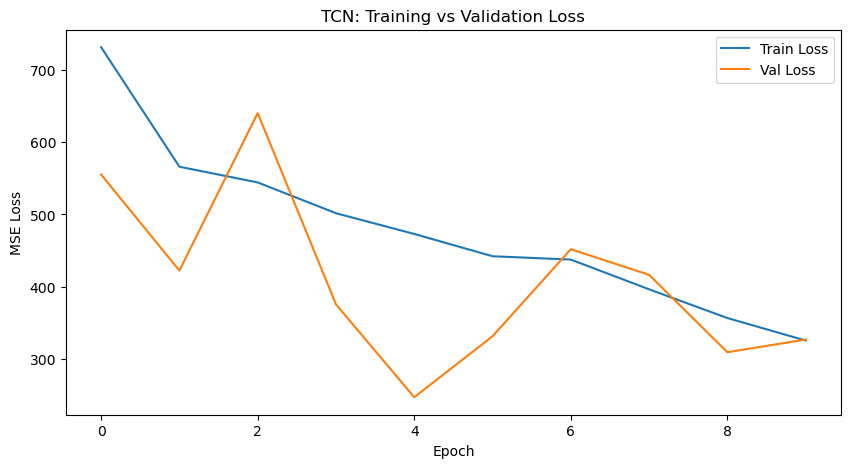

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


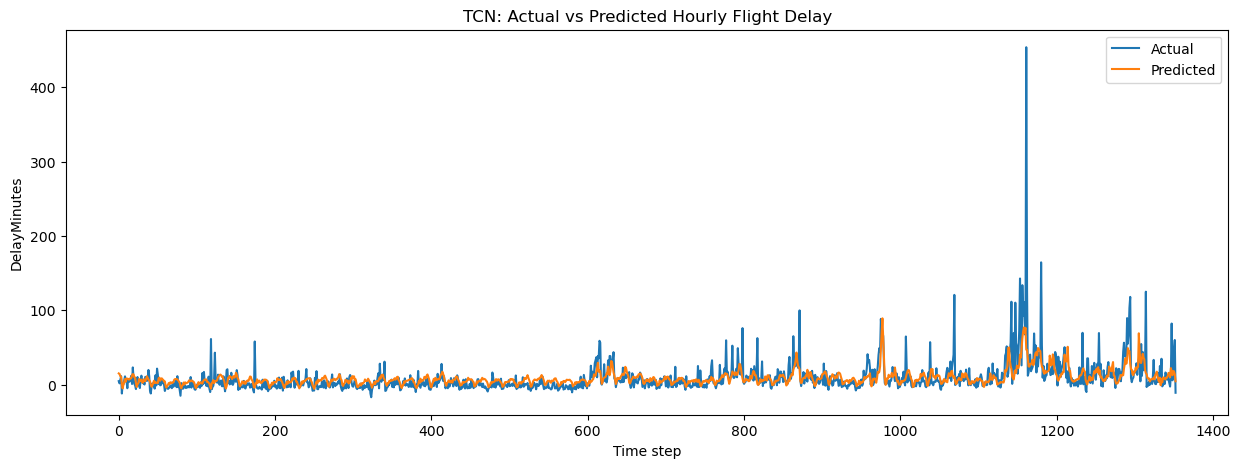

Best TCN -> MAE: 8.879, MSE: 324.892, RMSE: 18.025


In [40]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tcn import TCN
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
import matplotlib.pyplot as plt
import numpy as np

# hyperparams
param_grid_tcn = {
    "nb_filters": [32, 64],
    "kernel_size": [2, 3],
    "dropout": [0.1, 0.2],
    "learning_rate": [0.001, 0.0005],
    "batch_size": [32, 64],
    "epochs": [50]
}

# TCN
def build_tcn(input_shape, nb_filters=32, kernel_size=2, dropout=0.2, lr=0.001):
    model = Sequential([
        TCN(nb_filters=nb_filters, kernel_size=kernel_size, dilations=[1,2,4,8],
            activation='relu', input_shape=input_shape),
        Dropout(dropout),
        Dense(1, activation='linear')
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# placeholder
best_mse = float("inf")
best_params_tcn = {}
best_tcn_model = None

# searching
for params in ParameterGrid(param_grid_tcn):
    print("Testing TCN params:", params)
    model = build_tcn(
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
        nb_filters=params['nb_filters'],
        kernel_size=params['kernel_size'],
        dropout=params['dropout'],
        lr=params['learning_rate']
    )
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_split=0.2,
        epochs=params['epochs'],
        batch_size=params['batch_size'],
        callbacks=[es],
        verbose=0
    )
    
    # Predict and compute metrics
    y_pred_test = model.predict(X_test_seq).reshape(-1)
    mse = mean_squared_error(y_test_seq, y_pred_test)
    mae = mean_absolute_error(y_test_seq, y_pred_test)
    rmse = np.sqrt(mse)
    
    print(f"Params {params} -> MAE: {mae:.3f}, MSE: {mse:.3f}, RMSE: {rmse:.3f}")
    
    if mse < best_mse:
        best_mse = mse
        best_params_tcn = params
        best_tcn_model = model
        best_tcn_history = history

print("Best TCN params:", best_params_tcn)

# Plotting
plt.figure(figsize=(10,5))
plt.plot(best_tcn_history.history['loss'], label='Train Loss')
plt.plot(best_tcn_history.history['val_loss'], label='Val Loss')
plt.title("TCN: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# Plotting
y_pred_test = best_tcn_model.predict(X_test_seq).reshape(-1)
plt.figure(figsize=(15,5))
plt.plot(y_test_seq, label='Actual')
plt.plot(y_pred_test, label='Predicted')
plt.title("TCN: Actual vs Predicted Hourly Flight Delay")
plt.xlabel("Time step")
plt.ylabel("DelayMinutes")
plt.legend()
plt.show()

# metrics
mae = mean_absolute_error(y_test_seq, y_pred_test)
mse = mean_squared_error(y_test_seq, y_pred_test)
rmse = np.sqrt(mse)
print(f"Best TCN -> MAE: {mae:.3f}, MSE: {mse:.3f}, RMSE: {rmse:.3f}")


Testing Transformer params: {'batch_size': 32, 'dropout': 0.1, 'embed_dim': 32, 'epochs': 50, 'ff_dim': 64, 'learning_rate': 0.001, 'num_heads': 2}
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Params {'batch_size': 32, 'dropout': 0.1, 'embed_dim': 32, 'epochs': 50, 'ff_dim': 64, 'learning_rate': 0.001, 'num_heads': 2} -> MAE: 10.361, MSE: 376.635, RMSE: 19.407
Testing Transformer params: {'batch_size': 32, 'dropout': 0.1, 'embed_dim': 32, 'epochs': 50, 'ff_dim': 64, 'learning_rate': 0.001, 'num_heads': 4}
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Params {'batch_size': 32, 'dropout': 0.1, 'embed_dim': 32, 'epochs': 50, 'ff_dim': 64, 'learning_rate': 0.001, 'num_heads': 4} -> MAE: 13.164, MSE: 431.722, RMSE: 20.778
Testing Transformer params: {'batch_size': 32, 'dropout': 0.1, 'embed_dim': 32, 'epochs': 50, 'ff_dim': 64, 'learning_rate': 0.0005, 'num_heads': 2}
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Params {'batch_size': 32, 'dropout': 0.1, 'embed_dim': 32, 'epochs': 50, 'ff_dim': 64, 'learning_r

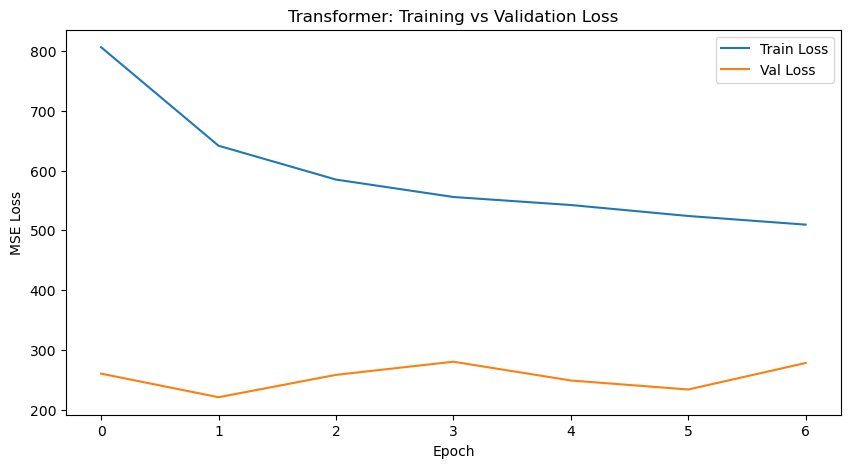

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


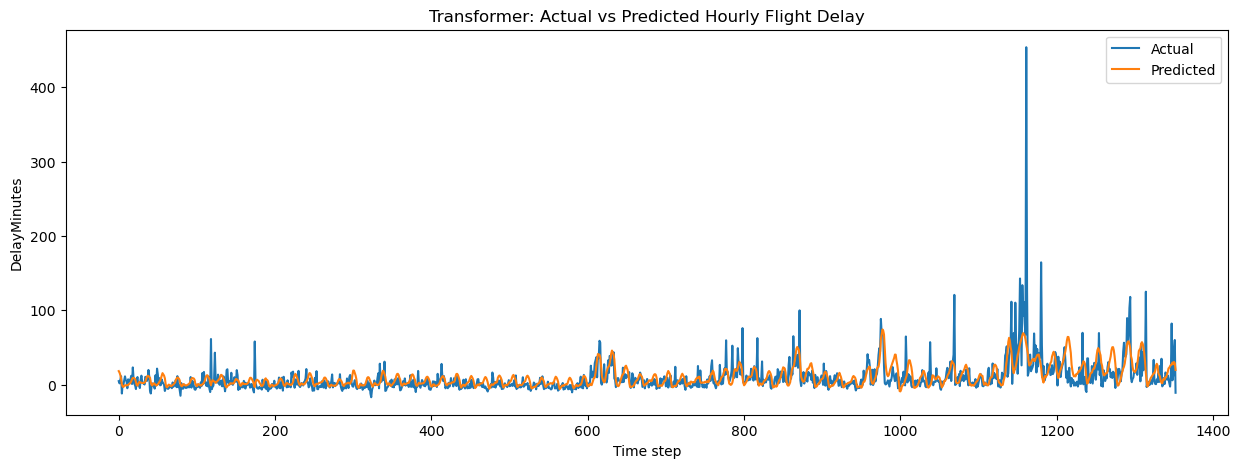

Best Transformer -> MAE: 9.742, MSE: 339.501, RMSE: 18.426


In [41]:

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LayerNormalization, Dropout, MultiHeadAttention, Add
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# hyperparameters
param_grid_trans = {
    "embed_dim": [32, 64],
    "num_heads": [2, 4],
    "ff_dim": [64, 128],
    "dropout": [0.1, 0.2],
    "learning_rate": [0.001, 0.0005],
    "batch_size": [32, 64],
    "epochs": [50]
}

# Transformer block
def transformer_block(x, embed_dim, num_heads, ff_dim, dropout=0.1):
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
    attn_output = Dropout(dropout)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(x + attn_output)

    ffn_output = Dense(ff_dim, activation='relu')(out1)
    ffn_output = Dense(embed_dim)(ffn_output)
    ffn_output = Dropout(dropout)(ffn_output)
    return LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

# Transformer
def build_transformer(input_shape, embed_dim=32, num_heads=2, ff_dim=64, dropout=0.1, lr=0.001):
    inputs = Input(shape=input_shape)
    x = Dense(embed_dim)(inputs)
    x = transformer_block(x, embed_dim, num_heads, ff_dim, dropout)
    x = Flatten()(x)
    outputs = Dense(1)(x)
    model = Model(inputs=inputs, outputs=outputs)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# placeholder
best_mse = float("inf")
best_params_trans = {}
best_trans_model = None

# searching
for params in ParameterGrid(param_grid_trans):
    print("Testing Transformer params:", params)
    model = build_transformer(
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
        embed_dim=params['embed_dim'],
        num_heads=params['num_heads'],
        ff_dim=params['ff_dim'],
        dropout=params['dropout'],
        lr=params['learning_rate']
    )
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_split=0.2,
        epochs=params['epochs'],
        batch_size=params['batch_size'],
        callbacks=[es],
        verbose=0
    )

    y_pred_test = model.predict(X_test_seq).reshape(-1)
    mse = mean_squared_error(y_test_seq, y_pred_test)
    mae = mean_absolute_error(y_test_seq, y_pred_test)
    rmse = np.sqrt(mse)
    print(f"Params {params} -> MAE: {mae:.3f}, MSE: {mse:.3f}, RMSE: {rmse:.3f}")

    if mse < best_mse:
        best_mse = mse
        best_params_trans = params
        best_trans_model = model
        best_trans_history = history

print("Best Transformer params:", best_params_trans)

# plotting
plt.figure(figsize=(10,5))
plt.plot(best_trans_history.history['loss'], label='Train Loss')
plt.plot(best_trans_history.history['val_loss'], label='Val Loss')
plt.title("Transformer: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# plotting
y_pred_test = best_trans_model.predict(X_test_seq).reshape(-1)
plt.figure(figsize=(15,5))
plt.plot(y_test_seq, label='Actual')
plt.plot(y_pred_test, label='Predicted')
plt.title("Transformer: Actual vs Predicted Hourly Flight Delay")
plt.xlabel("Time step")
plt.ylabel("DelayMinutes")
plt.legend()
plt.show()

# metrics
mae = mean_absolute_error(y_test_seq, y_pred_test)
mse = mean_squared_error(y_test_seq, y_pred_test)
rmse = np.sqrt(mse)
print(f"Best Transformer -> MAE: {mae:.3f}, MSE: {mse:.3f}, RMSE: {rmse:.3f}")


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
CNN -> MAE: 9.391, MSE: 335.323, RMSE: 18.312
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
LSTM -> MAE: 9.265, MSE: 330.798, RMSE: 18.188
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
RNN -> MAE: 11.216, MSE: 392.070, RMSE: 19.801
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
GRU -> MAE: 8.956, MSE: 341.020, RMSE: 18.467
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
TCN -> MAE: 8.879, MSE: 324.892, RMSE: 18.025
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Transformer -> MAE: 9.742, MSE: 339.501, RMSE: 18.426
         Model        MAE         MSE       RMSE
0          CNN   9.390953  335.322968  18.311826
1         LSTM   9.264734  330.798340  18.187862
2          RNN  11.216234  392.070038  19.800759
3          GRU   8.955575  341.019806  18.466722
4          TCN   8.879229  324.891663  18.024751
5  Transformer   9.741951  339.501190  18.425558


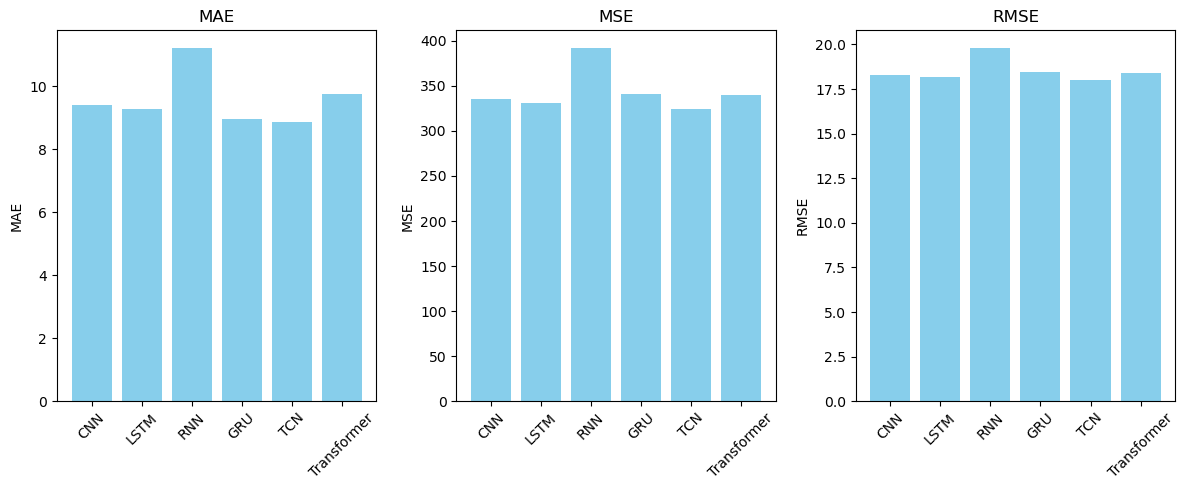

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Dictionary to store results
model_results = {}

# Function to record metrics
def record_metrics(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    model_results[model_name] = {"MAE": mae, "MSE": mse, "RMSE": rmse}
    print(f"{model_name} -> MAE: {mae:.3f}, MSE: {mse:.3f}, RMSE: {rmse:.3f}")

# Evaluate CNN
y_pred_cnn = best_cnn_model.predict(X_test_seq).reshape(-1)
record_metrics("CNN", y_test_seq, y_pred_cnn)

# Evaluate LSTM
y_pred_lstm = best_lstm_model.predict(X_test_seq).reshape(-1)
record_metrics("LSTM", y_test_seq, y_pred_lstm)

# Evaluate RNN
y_pred_rnn = best_rnn_model.predict(X_test_seq).reshape(-1)
record_metrics("RNN", y_test_seq, y_pred_rnn)

# Evaluate GRY
y_pred_gru = best_gru_model.predict(X_test_seq).reshape(-1)
record_metrics("GRU", y_test_seq, y_pred_gru)

# Evaluate FFNN
# y_pred_ffnn = best_ffnn_model.predict(X_test_seq).reshape(-1)
# record_metrics("FFNN", y_test_seq, y_pred_ffnn)

# Evaluate TCN
y_pred_tcn = best_tcn_model.predict(X_test_seq).reshape(-1)
record_metrics("TCN", y_test_seq, y_pred_tcn)

# Evaluate Transformer
y_pred_trans = best_trans_model.predict(X_test_seq).reshape(-1)
record_metrics("Transformer", y_test_seq, y_pred_trans)

# Convert results to DataFrame for plotting
results_df = pd.DataFrame(model_results).T
results_df = results_df.reset_index().rename(columns={"index": "Model"})
print(results_df)

# plotting
metrics = ['MAE', 'MSE', 'RMSE']
plt.figure(figsize=(12,5))
for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i+1)
    plt.bar(results_df['Model'], results_df[metric], color='skyblue')
    plt.title(metric)
    plt.xticks(rotation=45)
    plt.ylabel(metric)
plt.tight_layout()
plt.show()


# Analysis:

##  Best model by RMSE and MAE:

- TCN (Temporal Convolutional Network) has the lowest MAE (8.88) and lowest RMSE (18.02).
- Lower MAE and RMSE indicate that on average, its predictions are closer to the actual flight delays than other models.

### Why TCN might be better:
- TCNs use causal convolutions, which are great for time series because they respect temporal order.
- They can capture long-range dependencies more efficiently than standard RNNs or LSTMs without the vanishing gradient problems.
- CNN-based models like TCNs can also process sequences in parallel, making them more stable for longer sequences.

### Other observations:
- GRU is close to TCN in MAE but has slightly higher RMSE.
- LSTM and CNN perform reasonably well, better than vanilla RNN.
- Transformer has decent performance but in this dataset, probably overkill given the hourly averaged data—it excels in very long sequences or high-dimensional inputs.
- Vanilla RNN performs the worst, likely due to difficulty learning long-term dependencies.

### Conclusion:
- TCN is the best model for predicting hourly average flight delays in this dataset, mainly because it handles temporal dependencies effectively and avoids issues RNNs face with long sequences

##  Further explanation:
 input data is hourly averages of flight delays from JFK.
This is aggregated over flights, so the data is already smoothed. We are not predicting per-flight delays, but the average delay per hour.

## Why TCN performs best

- TCNs are 1D convolutional networks designed for sequences. They:
- Use causal convolutions → predictions only depend on past data.
- Capture long-term dependencies efficiently → can “see” hours, days, or even weeks in past sequences.
- Avoid the vanishing gradient problem of RNNs/LSTMs/GRUs.
- Your sequences are hourly averages, so TCN can effectively detect patterns like rush hours, weekly trends, or holidays, which fits this type of data well.

## Why other models lag
- RNN: struggles with long sequences; poor MAE/MSE reflects this.
- LSTM/GRU: handle long sequences better than vanilla RNN, but may not extract local temporal patterns as efficiently as TCNs.
- CNN: good for local patterns but not inherently sequential; may miss long-term dependencies.
- Transformer: excellent for very long sequences or highly complex data, but your data is already aggregated hourly, so it may be overkill, leading to slightly worse metrics.

## Caveat
- Differences in MAE/RMSE between TCN, GRU, and LSTM are small (~0.1–0.3).
- In practice, any of TCN, GRU, or LSTM would perform reasonably well, but TCN has a slight edge for sequence-based regression with smoothed time series.

## Conclusion:
TCN is slightly better because it captures temporal patterns efficiently in an hourly-averaged dataset.

But if you switched to per-flight data (more irregular, more noise), LSTM or GRU might perform better.